In [11]:
import os, random, shutil
import numpy, cv2, albumentations, albucore, timm, torchinfo
from glob import glob
import numpy as np
import pandas as pd
from typing import List, Tuple
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import timm
from torchinfo import summary

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 3e-4
MODEL_NAME = "efficientnet_b0"
NUM_WORKERS = 2


DEVICE: cuda


In [19]:
ZIP_PATH = "/content/data.zip"
TARGET_ROOT = "/content/data"

os.makedirs(TARGET_ROOT, exist_ok=True)
!unzip -q "/content/data.zip" -d "/content/data"

for p in sorted(glob(os.path.join(TARGET_ROOT, "*"))):
    print(">", p)


> /content/data/garbage_classification


In [20]:
# Auto-detect dataset root (split vs flat)
def has_images(path):
    exts = (".jpg",".jpeg",".png",".bmp",".webp")
    try:
        return any([f.lower().endswith(exts) for f in os.listdir(path)])
    except:
        return False

def find_dataset_root(root):
    items = [d for d in glob(os.path.join(root, "*")) if os.path.isdir(d)]
    names = [os.path.basename(d).lower() for d in items]

    if "train" in names and any(n in names for n in ["val","valid","validation"]) and "test" in names:
        return root, "split"

    class_like = [d for d in items if os.path.isdir(d)]
    if len(class_like) >= 2:
        ratio = 0
        for d in class_like:
            if any([p.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp")) for p in glob(os.path.join(d,"*"))]):
                ratio += 1
        if ratio >= max(2, int(0.6*len(class_like))):
            return root, "flat"

    for d in items:
        subdirs = [s for s in glob(os.path.join(d, "*")) if os.path.isdir(s)]
        if subdirs:
            r, t = find_dataset_root(d)
            if r: return r, t

    return None, None

DATA_ROOT, STRUCTURE = find_dataset_root(TARGET_ROOT)
print("DATA_ROOT:", DATA_ROOT, "| STRUCTURE:", STRUCTURE)


DATA_ROOT: /content/data/garbage_classification | STRUCTURE: flat


In [21]:
# region: Split if needed
def ensure_split_if_needed(data_root, structure, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    if structure == "split":
        for tr, va, te in [("train","val","test"), ("train","valid","test"), ("train","validation","test")]:
            trp, vap, tep = os.path.join(data_root,tr), os.path.join(data_root,va), os.path.join(data_root,te)
            if all(os.path.isdir(p) for p in [trp,vap,tep]):
                return trp, vap, tep
        raise RuntimeError("train/val/test.")
    elif structure == "flat":
        classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])
        split_root = "/content/split_data"
        if os.path.exists(split_root): shutil.rmtree(split_root)
        for c in classes:
            imgs = [f for f in glob(os.path.join(data_root, c, "*")) if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp"))]
            random.shuffle(imgs)
            n = len(imgs); tr = int(n*train_ratio); vr = int(n*val_ratio)
            parts = {"train": imgs[:tr], "val": imgs[tr:tr+vr], "test": imgs[tr+vr:]}
            for split, files in parts.items():
                os.makedirs(os.path.join(split_root, split, c), exist_ok=True)
                for f in files:
                    shutil.copy(f, os.path.join(split_root, split, c, os.path.basename(f)))
        return os.path.join(split_root,"train"), os.path.join(split_root,"val"), os.path.join(split_root,"test")

train_dir, val_dir, test_dir = ensure_split_if_needed(DATA_ROOT, STRUCTURE)
print("train_dir:", train_dir)
print("val_dir  :", val_dir)
print("test_dir :", test_dir)

def get_classes(path): return sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
classes = get_classes(train_dir)
print("Classes:", classes, "| num_classes:", len(classes))
# endregion


train_dir: /content/split_data/train
val_dir  : /content/split_data/val
test_dir : /content/split_data/test
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass'] | num_classes: 12


Train counts: {'battery': 661, 'biological': 689, 'brown-glass': 424, 'cardboard': 623, 'clothes': 3727, 'green-glass': 440, 'metal': 538, 'paper': 735, 'plastic': 605, 'shoes': 1383, 'trash': 487, 'white-glass': 542}
Val counts  : {'battery': 141, 'biological': 147, 'brown-glass': 91, 'cardboard': 133, 'clothes': 798, 'green-glass': 94, 'metal': 115, 'paper': 157, 'plastic': 129, 'shoes': 296, 'trash': 104, 'white-glass': 116}
Test counts : {'battery': 143, 'biological': 149, 'brown-glass': 92, 'cardboard': 135, 'clothes': 800, 'green-glass': 95, 'metal': 116, 'paper': 158, 'plastic': 131, 'shoes': 298, 'trash': 106, 'white-glass': 117}


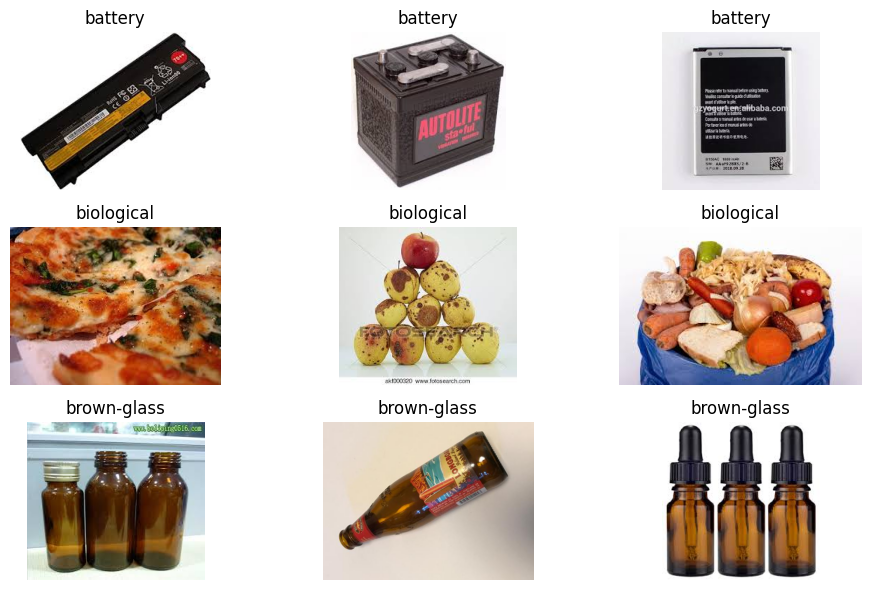

In [22]:
# EDA quick look
def count_images(root):
    counts = {}
    for c in get_classes(root):
        n = len([f for f in glob(os.path.join(root, c, "*")) if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp"))])
        counts[c] = n
    return counts

print("Train counts:", count_images(train_dir))
print("Val counts  :", count_images(val_dir))
print("Test counts :", count_images(test_dir))

# show samples
sample_paths = []
for c in classes[:3]:
    sample_paths += glob(os.path.join(train_dir, c, "*"))[:3]

plt.figure(figsize=(10,6))
for i,p in enumerate(sample_paths[:9]):
    img = Image.open(p).convert("RGB")
    plt.subplot(3,3,i+1); plt.imshow(img); plt.title(os.path.basename(os.path.dirname(p))); plt.axis("off")
plt.tight_layout(); plt.show()

In [25]:
# Datasets & Augs (stable & simple)
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_tfms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.7),
    A.ColorJitter(p=0.30),
    A.Normalize(),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

class ImageFolderA(Dataset):
    def __init__(self, root, classes, tfms):
        self.samples = []
        self.classes = classes
        self.class_to_idx = {c:i for i,c in enumerate(classes)}
        for c in classes:
            for f in glob(os.path.join(root, c, "*")):
                if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp")):
                    self.samples.append((f, self.class_to_idx[c]))
        self.tfms = tfms

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fp, y = self.samples[idx]
        img = cv2.imread(fp); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.tfms(image=img)["image"]
        return img, y

train_ds = ImageFolderA(train_dir, classes, train_tfms)
val_ds   = ImageFolderA(val_dir,   classes, val_tfms)
test_ds  = ImageFolderA(test_dir,  classes, val_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


(10854, 2321, 2340)

In [26]:
num_classes = len(classes)
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=num_classes).to(DEVICE)
summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipython-input-898098689.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [27]:
# Train & Eval
def evaluate(model, loader):
    model.eval()
    preds_all, targ_all = [], []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            preds_all.append(preds.cpu().numpy()); targ_all.append(y.cpu().numpy())
    preds_all = np.concatenate(preds_all); targ_all = np.concatenate(targ_all)
    acc = accuracy_score(targ_all, preds_all)
    f1  = f1_score(targ_all, preds_all, average="macro")
    return acc, f1, targ_all, preds_all

def train_one_epoch(model, loader):
    model.train()
    running = 0.0
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        running += loss.item() * x.size(0)
    return running/len(loader.dataset)

best_f1, patience, bad = -1, 3, 0
for ep in range(1, EPOCHS+1):
    tr_loss = train_one_epoch(model, train_dl)
    val_acc, val_f1, _, _ = evaluate(model, val_dl)
    scheduler.step()

    print(f"Epoch {ep:02d}/{EPOCHS} | loss={tr_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping ✅"); break

if 'best_state' in locals():
    model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})


/tmp/ipython-input-3728035806.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 01/10 | loss=0.4741 | val_acc=0.9349 | val_f1=0.9036


/tmp/ipython-input-3728035806.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 02/10 | loss=0.1583 | val_acc=0.9479 | val_f1=0.9215


/tmp/ipython-input-3728035806.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

Epoch 08/10 | loss=0.0191 | val_acc=0.9642 | val_f1=0.9477


/tmp/ipython-input-3728035806.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 09/10 | loss=0.0169 | val_acc=0.9625 | val_f1=0.9438


/tmp/ipython-input-3728035806.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 10/10 | loss=0.0106 | val_acc=0.9638 | val_f1=0.9465


TEST: acc=0.9658, macroF1=0.9495

Classification Report:
              precision    recall  f1-score   support

     battery     0.9861    0.9930    0.9895       143
  biological     0.9136    0.9933    0.9518       149
 brown-glass     0.8776    0.9348    0.9053        92
   cardboard     0.9924    0.9704    0.9813       135
     clothes     0.9950    0.9888    0.9918       800
 green-glass     0.9747    0.8105    0.8851        95
       metal     0.9024    0.9569    0.9289       116
       paper     0.9625    0.9747    0.9686       158
     plastic     0.9457    0.9313    0.9385       131
       shoes     0.9637    0.9799    0.9717       298
       trash     0.9608    0.9245    0.9423       106
 white-glass     0.9558    0.9231    0.9391       117

    accuracy                         0.9658      2340
   macro avg     0.9525    0.9484    0.9495      2340
weighted avg     0.9666    0.9658    0.9657      2340



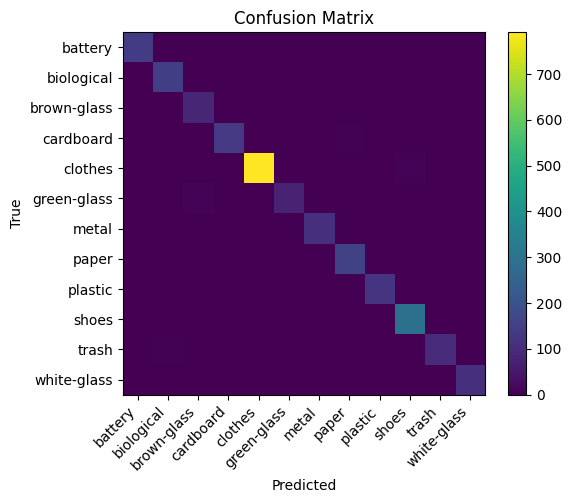

In [28]:
#Final Eval
test_acc, test_f1, y_true, y_pred = evaluate(model, test_dl)
print(f"TEST: acc={test_acc:.4f}, macroF1={test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=45, ha="right"); plt.yticks(ticks, classes)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()
